# DQN Atari Pong Demo

Thin demo surface for the repo-native DQN Atari workflow. The implementation lives in `model/rl_workflow.py`; this notebook configures a run, calls workflow functions, and inspects saved artifacts. Smoke and debug profiles validate plumbing only, not benchmark quality.

In [1]:
from pathlib import Path
import csv
import importlib
import json
import sys

import matplotlib.pyplot as plt


def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "model").is_dir() and (candidate / "datasets").is_dir():
            return candidate
    raise RuntimeError("Could not find NN-kNN repo root from this notebook.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import model.rl_workflow as rl_workflow
rl_workflow = importlib.reload(rl_workflow)

evaluate_dqn = rl_workflow.evaluate_dqn
load_dqn_checkpoint = rl_workflow.load_dqn_checkpoint
make_dqn_config = rl_workflow.make_dqn_config
train_dqn = rl_workflow.train_dqn

ROOT

WindowsPath('c:/Users/ellio/OneDrive/Desktop/NN-kNN')

## Configuration

Atari requires Gymnasium Atari dependencies and accepted ROM license installation. Use `PROFILE = "smoke"` for a quick plumbing check, `"debug"` for an interactive development run, and reserve longer profiles for planned experiments.

In [2]:
TASK = "pong"
PROFILE = "gold"  # use "smoke" for plumbing only or "fast" for a longer exploratory run
SEED = 0
DEVICE = None  # use None for repo default, or set "cpu" / "cuda"

RUN_TRAINING = True  # set True to launch training from this notebook
CHECKPOINT_PATH = None  # set Path("results/rl/.../checkpoint.pt") to pin one run


def latest_dqn_checkpoint(task=TASK, profile=PROFILE, parent=Path("results/rl")):
    pattern = f"dqn_{task}_*/checkpoint.pt"
    checkpoints = sorted(parent.glob(pattern), key=lambda path: path.stat().st_mtime, reverse=True)
    for checkpoint_path in checkpoints:
        try:
            checkpoint = load_dqn_checkpoint(checkpoint_path, device=DEVICE)
        except Exception:
            continue
        config = checkpoint["config"]
        task_data = checkpoint["task"]
        if task_data.get("name") == task and config.profile == profile:
            return checkpoint_path
    raise FileNotFoundError(
        f"No DQN checkpoint found for task={task!r} and profile={profile!r} under {parent}. "
        "Set RUN_TRAINING=True or provide CHECKPOINT_PATH."
    )


cfg = make_dqn_config(PROFILE, task_name=TASK, seed=SEED)
{
    "task": TASK,
    "profile": cfg.profile,
    "total_timesteps": cfg.total_timesteps,
    "eval_episodes": cfg.eval_episodes,
    "network_kind": cfg.network_kind,
    "run_training": RUN_TRAINING,
}

{'task': 'pong',
 'profile': 'gold',
 'total_timesteps': 1000000,
 'eval_episodes': 10,
 'network_kind': 'cnn',
 'run_training': True}

In [3]:
if RUN_TRAINING:
    state = train_dqn(TASK, cfg, device=DEVICE, progress=True)
    checkpoint_path = state["checkpoint_path"]
else:
    checkpoint_path = Path(CHECKPOINT_PATH) if CHECKPOINT_PATH is not None else latest_dqn_checkpoint()
    state = None

checkpoint_path

[dqn] step=846 episode=1 return=-21.0 length=846 epsilon=0.998 loss=None
[dqn] step=1663 episode=2 return=-21.0 length=817 epsilon=0.997 loss=None
[dqn] step=2607 episode=3 return=-20.0 length=944 epsilon=0.995 loss=None
[dqn] step=3410 episode=4 return=-21.0 length=803 epsilon=0.994 loss=None
[dqn] step=4251 episode=5 return=-21.0 length=841 epsilon=0.992 loss=None
[dqn] step=8918 episode=10 return=-20.0 length=834 epsilon=0.983 loss=None
[dqn] step=18383 episode=20 return=-20.0 length=939 epsilon=0.965 loss=None
[dqn] step=27642 episode=30 return=-21.0 length=963 epsilon=0.947 loss=None
[dqn] step=36928 episode=40 return=-21.0 length=849 epsilon=0.930 loss=None
[dqn] step=46226 episode=50 return=-21.0 length=969 epsilon=0.912 loss=None
[dqn][eval] step=50000 mean_return=-21.00 max_return=-21.00
[dqn] step=55722 episode=60 return=-20.0 length=928 epsilon=0.894 loss=0.00031845952617004514
[dqn] step=64569 episode=70 return=-20.0 length=837 epsilon=0.877 loss=0.030050482600927353
[dqn] 

WindowsPath('results/rl/dqn_pong_20260708_133010_927252/checkpoint.pt')

In [4]:
loaded = load_dqn_checkpoint(checkpoint_path, device=DEVICE)
summary_path = checkpoint_path.parent / "summary.json"
summary = json.loads(summary_path.read_text(encoding="utf-8")) if summary_path.exists() else {}
{
    "checkpoint": str(checkpoint_path),
    "task": loaded["task"].get("name"),
    "env_id": loaded["task"].get("env_id"),
    "profile": loaded["config"].profile,
    "network_kind": loaded["config"].network_kind,
    "final_eval": summary.get("final_eval"),
    "training_efficiency": summary.get("training_efficiency"),
}

{'checkpoint': 'results\\rl\\dqn_pong_20260708_133010_927252\\checkpoint.pt',
 'task': 'pong',
 'env_id': 'ALE/Pong-v5',
 'profile': 'gold',
 'network_kind': 'cnn',
 'final_eval': {'episodes': 10,
  'seed': 10000,
  'mean_return': -21.0,
  'std_return': 0.0,
  'min_return': -21.0,
  'max_return': -21.0,
  'mean_length': 758.4000244140625},
 'training_efficiency': {'best_model_step': 1000000,
  'best_model_training_fraction': 1.0,
  'first_success_step': None,
  'first_success_training_fraction': None,
  'best_minus_last_return': 0.0,
  'budget_interpretation': 'final_is_best_check_for_underfit'}}

In [5]:
def read_csv_rows(path):
    if not path.exists() or path.stat().st_size == 0:
        return []
    with path.open(newline="", encoding="utf-8") as handle:
        return list(csv.DictReader(handle))

training_rows = read_csv_rows(checkpoint_path.parent / "training_metrics.csv")
eval_rows = read_csv_rows(checkpoint_path.parent / "eval_metrics.csv")
len(training_rows), len(eval_rows)

(1205, 19)

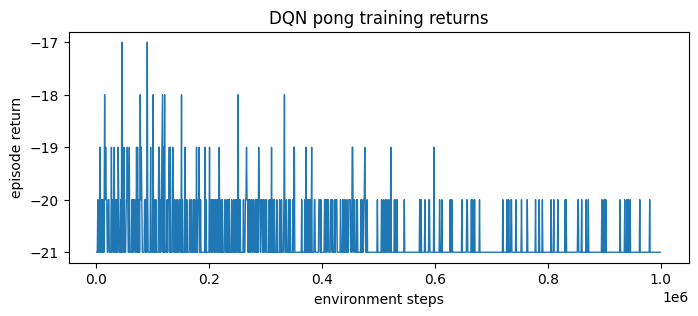

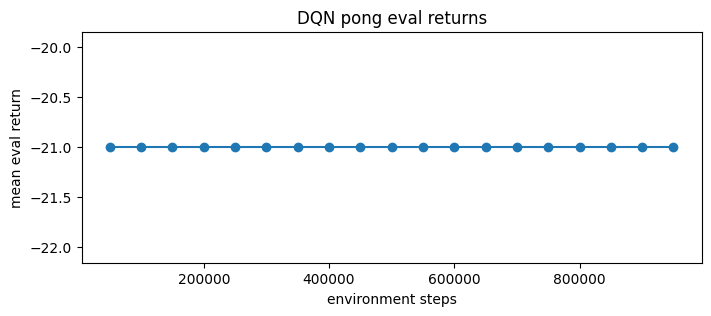

In [6]:
if training_rows:
    steps = [int(row["global_step"]) for row in training_rows]
    returns = [float(row["episode_return"]) for row in training_rows]
    plt.figure(figsize=(8, 3))
    plt.plot(steps, returns, linewidth=1)
    plt.xlabel("environment steps")
    plt.ylabel("episode return")
    plt.title(f"DQN {TASK} training returns")
    plt.show()

if eval_rows:
    eval_steps = [int(row["global_step"]) for row in eval_rows]
    mean_returns = [float(row["mean_return"]) for row in eval_rows]
    plt.figure(figsize=(8, 3))
    plt.plot(eval_steps, mean_returns, marker="o")
    plt.xlabel("environment steps")
    plt.ylabel("mean eval return")
    plt.title(f"DQN {TASK} eval returns")
    plt.show()

In [7]:
metrics = evaluate_dqn(
    TASK,
    loaded["model"],
    episodes=loaded["config"].eval_episodes,
    seed=loaded["config"].eval_seed,
    device=loaded["device"],
)
{k: v for k, v in metrics.items() if k != "episode_metrics"}

{'episodes': 10,
 'seed': 10000,
 'mean_return': -21.0,
 'std_return': 0.0,
 'min_return': -21.0,
 'max_return': -21.0,
 'mean_length': 758.4000244140625}